# 06 — Explainability (locked tuned HistGradientBoosting)

**Scope:** the locked Phase 7 candidate, fitted on the training set. The test set is not loaded.

**Methods** (`src/churn/explain.py`)
- **SHAP (TreeExplainer, tree-path-dependent):** exact per-customer contributions computed on the pipeline's *own* fitted preprocessor output (no re-implemented preprocessing). One-hot columns are summed back to their original feature.
- **Grouped permutation importance:** drop in held-out ROC-AUC (5-fold CV on the training set) when a feature, or a group of correlated features, is shuffled.

**How to read SHAP values here**
- Values are in **log-odds** of churn. For each customer: `base value + sum of contributions = model log-odds`, and `probability = 1 / (1 + e^(−log-odds))`.
- Contributions add up in log-odds, **not** in probability: the same +0.5 log-odds moves a 10% customer much less (in percentage points) than a 50% customer.
- They describe how **this model** uses a feature for this customer, relative to the model's average. They are associations, **not causes** — changing a customer's contract would not necessarily change their churn by the shown amount.
- **Correlated features share credit.** `tenure`, `TotalCharges` and `MonthlyCharges` carry overlapping information (TotalCharges ≈ tenure × MonthlyCharges), as do `InternetService` and the six add-ons (shared "No internet service" level). How the model splits credit among them is somewhat arbitrary, so group totals are more reliable than individual values within a group.

In [1]:
import json
import warnings
from functools import partial

warnings.filterwarnings("ignore", message="IProgress not found")  # shap imports tqdm; no widgets needed

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from churn.config import FIGURES_DIR, REPORTS_DIR
from churn.data import load_dataset, split_features_target, split_train_test
from churn.explain import (
    CORRELATED_GROUPS,
    cv_permutation_importance,
    explain_prediction,
    global_shap_importance,
    grouped_shap_values,
    make_explainer,
)
from churn.preprocessing import model_features
from churn.tuning import make_tuned_pipeline

%matplotlib inline
pd.set_option("display.precision", 4)

TEXT, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
BLUE, ORANGE = "#2a78d6", "#eb6834"  # lowers risk / raises risk
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": TEXT,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10, "legend.frameon": False,
})


def save(fig, name):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## 1. Fit the locked candidate on the training set

In [2]:
locked = json.loads((REPORTS_DIR / "locked_decisions_tuned.json").read_text())
assert locked["test_set_evaluated"] is False
THRESHOLD = locked["threshold"]

train_df, _ = split_train_test(load_dataset())  # test half discarded
X_train, y_train = split_features_target(train_df)

make_pipeline = partial(make_tuned_pipeline, locked["model"], locked["hyperparameters"])
pipeline = make_pipeline().fit(X_train, y_train)
explainer = make_explainer(pipeline)
print(f"{locked['model']} fitted on {len(X_train)} training rows; operating threshold {THRESHOLD}")

HistGradientBoosting fitted on 5634 training rows; operating threshold 0.3


In [3]:
shap_result = grouped_shap_values(pipeline, explainer, X_train)
shap_values = shap_result.values

# Additivity check: base + contributions reproduces the model's log-odds for every customer.
max_error = np.abs(shap_values.sum(axis=1) + shap_result.base_value - pipeline.decision_function(X_train)).max()
print(f"Base value: {shap_result.base_value:.3f} log-odds (= {1 / (1 + np.exp(-shap_result.base_value)):.1%})")
print(f"Max additivity error: {max_error:.1e}")

Base value: -1.504 log-odds (= 18.2%)
Max additivity error: 6.2e-15


## 2. Global importance

In [4]:
shap_importance = global_shap_importance(shap_values)

group_shap = pd.Series({
    name: shap_values[cols].sum(axis=1).abs().mean() for name, cols in CORRELATED_GROUPS.items()
})

permutation_groups = {f: [f] for f in model_features()} | CORRELATED_GROUPS
permutation = cv_permutation_importance(make_pipeline, X_train, y_train, permutation_groups)

global_table = pd.DataFrame({
    "mean |SHAP| (log-odds)": pd.concat([shap_importance, group_shap]),
    "ROC-AUC drop when shuffled": permutation["mean"],
    "drop std": permutation["std"],
}).sort_values("ROC-AUC drop when shuffled", ascending=False)
global_table.to_csv(REPORTS_DIR / "explainability_global_importance.csv")
global_table

,mean |SHAP| (log-odds),ROC-AUC drop when shuffled,drop std
Contract,0.7673,9.3857e-02,1.4212e-02
internet service + add-ons,0.5072,6.3471e-02,1.3086e-02
tenure + charges,0.4045,5.0799e-02,9.9376e-03
tenure,0.3541,3.7665e-02,9.7975e-03
InternetService,0.2730,1.8693e-02,9.4733e-03
MonthlyCharges,0.1536,7.4845e-03,4.9244e-03
OnlineSecurity,0.2178,4.8649e-03,2.7585e-03
PaymentMethod,0.1448,4.6969e-03,2.0904e-03
TechSupport,0.1547,3.5072e-03,2.0539e-03
PaperlessBilling,0.0975,3.3621e-03,2.1099e-03


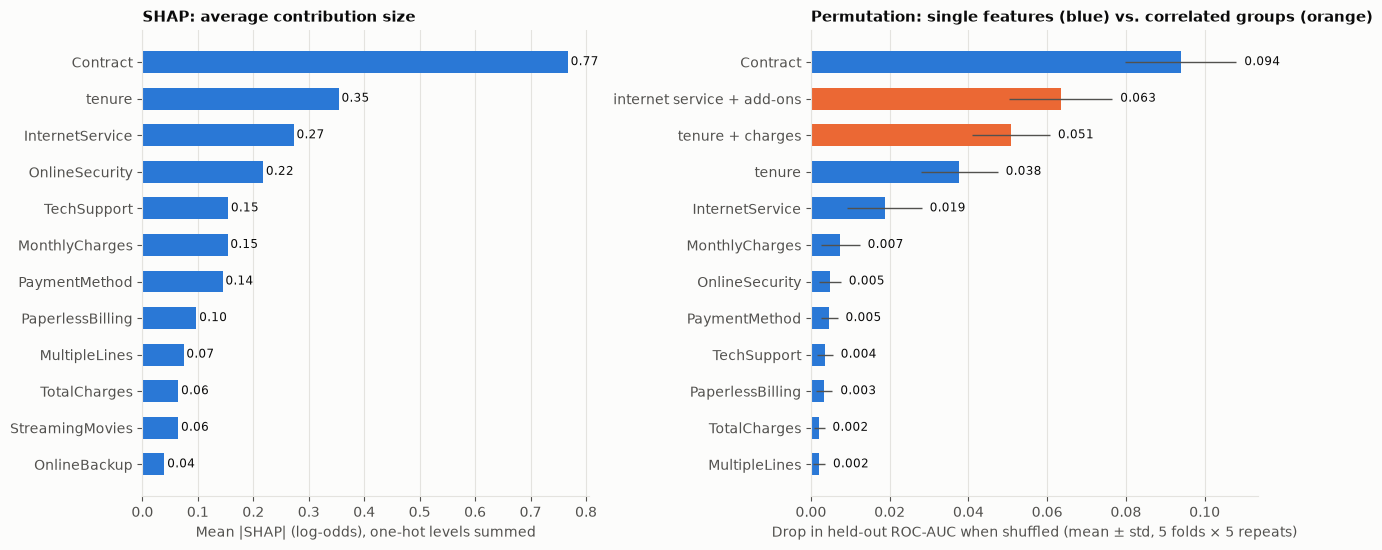

In [5]:
fig, (ax_shap, ax_perm) = plt.subplots(1, 2, figsize=(13, 5.6))

top = shap_importance.head(12)[::-1]
ax_shap.barh(top.index, top.values, color=BLUE, height=0.6)
for y, v in enumerate(top.values):
    ax_shap.text(v + 0.005, y, f"{v:.2f}", va="center", fontsize=8.5, color=TEXT)
ax_shap.set_xlabel("Mean |SHAP| (log-odds), one-hot levels summed")
ax_shap.set_title("SHAP: average contribution size")
ax_shap.grid(axis="y", visible=False)

perm = permutation["mean"].drop([f for f in model_features() if permutation.loc[f, "mean"] < 0.002], errors="ignore")
perm = perm.sort_values()
is_group = perm.index.isin(list(CORRELATED_GROUPS))
ax_perm.barh(perm.index, perm.values, xerr=permutation.loc[perm.index, "std"], height=0.6,
             color=np.where(is_group, ORANGE, BLUE), error_kw={"ecolor": MUTED, "lw": 1})
for y, (v, s) in enumerate(zip(perm.values, permutation.loc[perm.index, "std"])):
    ax_perm.text(v + s + 0.002, y, f"{v:.3f}", va="center", fontsize=8.5, color=TEXT)
ax_perm.set_xlabel("Drop in held-out ROC-AUC when shuffled (mean ± std, 5 folds × 5 repeats)")
ax_perm.set_title("Permutation: single features (blue) vs. correlated groups (orange)")
ax_perm.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "20_global_importance")
plt.show()

Features with a permutation drop below 0.002 ROC-AUC are omitted from the right panel. Note how the **groups** (orange) matter far more than any of their members shuffled alone: when one correlated feature is shuffled, the model can still partly rely on its partners.

## 3. Direction of effects

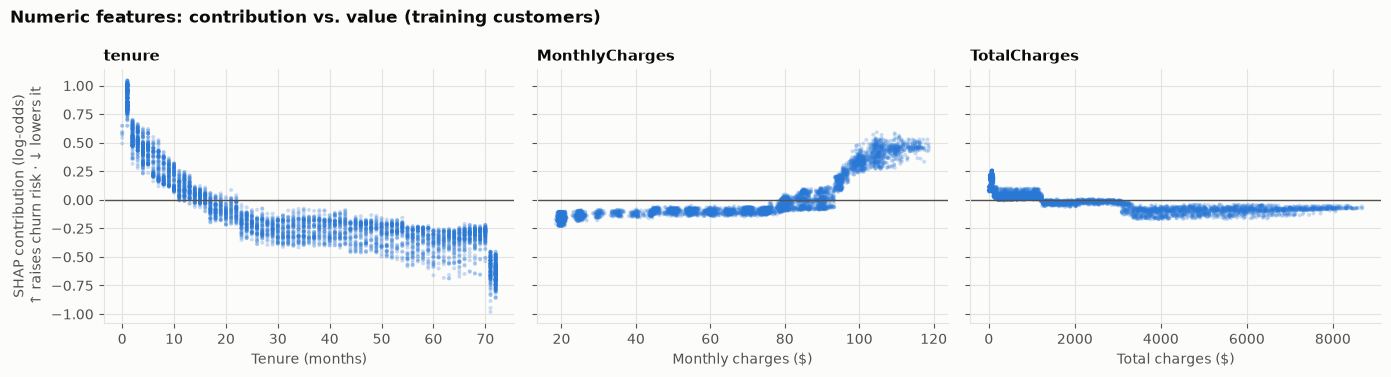

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
rng = np.random.default_rng(0)
for ax, feature, label in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"],
                              ["Tenure (months)", "Monthly charges ($)", "Total charges ($)"]):
    ax.scatter(X_train[feature], shap_values[feature], s=8, alpha=0.25, color=BLUE, edgecolors="none")
    ax.axhline(0, color=MUTED, lw=1)
    ax.set_xlabel(label)
    ax.set_title(feature)
axes[0].set_ylabel("SHAP contribution (log-odds)\n↑ raises churn risk · ↓ lowers it")
fig.suptitle("Numeric features: contribution vs. value (training customers)", x=0.01, ha="left",
             fontweight="bold", color=TEXT)
fig.tight_layout()
save(fig, "21_numeric_contributions")
plt.show()

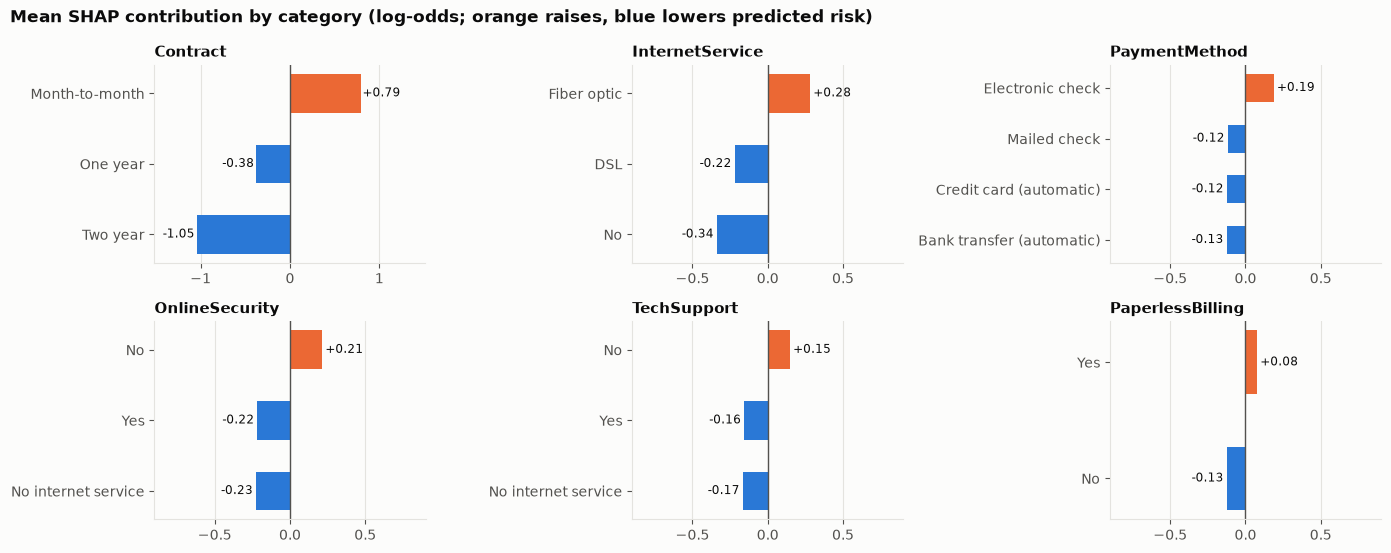

In [7]:
categorical_to_show = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "PaperlessBilling"]
fig, axes = plt.subplots(2, 3, figsize=(14, 5.6))
for ax, feature in zip(axes.flat, categorical_to_show):
    by_level = shap_values[feature].groupby(X_train[feature]).mean().sort_values()
    colors = np.where(by_level.values > 0, ORANGE, BLUE)
    ax.barh([str(i) for i in by_level.index], by_level.values, color=colors, height=0.55)
    for y, v in enumerate(by_level.values):
        ax.text(v + (0.02 if v >= 0 else -0.02), y, f"{v:+.2f}", va="center",
                ha="left" if v >= 0 else "right", fontsize=8.5, color=TEXT)
    ax.axvline(0, color=MUTED, lw=1)
    lim = max(0.9, np.abs(by_level.values).max() * 1.45)
    ax.set_xlim(-lim, lim)
    ax.grid(axis="y", visible=False)
    ax.set_title(feature)
fig.suptitle("Mean SHAP contribution by category (log-odds; orange raises, blue lowers predicted risk)",
             x=0.01, ha="left", fontweight="bold", color=TEXT)
fig.tight_layout()
save(fig, "22_categorical_contributions")
plt.show()

## 4. Local explanations (individual customers)

Three training customers chosen deterministically: highest predicted risk, the customer closest to the operating threshold, and lowest predicted risk. (Training customers are used because the test set is off-limits; these are in-sample predictions and illustrate the mechanism, not model accuracy.)

In [8]:
proba = pd.Series(pipeline.predict_proba(X_train)[:, 1], index=X_train.index)
examples = {
    "Highest risk": proba.idxmax(),
    "Near threshold": (proba - THRESHOLD).abs().idxmin(),
    "Lowest risk": proba.idxmin(),
}

local = {}
for label, idx in examples.items():
    explanation = explain_prediction(pipeline, explainer, X_train.loc[[idx]])
    local[label] = explanation
    decision = "flag (churn risk)" if explanation.predicted_probability >= THRESHOLD else "do not flag"
    print(f"\n=== {label}: customer {train_df.loc[idx, 'customerID']} — "
          f"P(churn) = {explanation.predicted_probability:.1%} → {decision} at threshold {THRESHOLD} "
          f"(actual churn: {int(y_train.loc[idx])}) ===")
    print(f"base {explanation.base_value:+.3f} + contributions {explanation.contributions['contribution'].sum():+.3f} "
          f"= {explanation.predicted_log_odds:+.3f} log-odds")
    display(explanation.top(6))


=== Highest risk: customer 7216-EWTRS — P(churn) = 86.7% → flag (churn risk) at threshold 0.3 (actual churn: 1) ===
base -1.504 + contributions +3.383 = +1.878 log-odds


,feature,value,contribution
0,Contract,Month-to-month,0.8865
1,tenure,1,0.7015
2,InternetService,Fiber optic,0.2773
3,OnlineSecurity,No,0.2613
4,MonthlyCharges,100.8,0.2606
5,TotalCharges,100.8,0.2021
6,12 other features,,0.7933



=== Near threshold: customer 7147-AYBAA — P(churn) = 30.0% → flag (churn risk) at threshold 0.3 (actual churn: 0) ===
base -1.504 + contributions +0.657 = -0.847 log-odds


,feature,value,contribution
0,Contract,Month-to-month,0.7520
1,tenure,37,-0.3706
2,InternetService,Fiber optic,0.3383
3,PaymentMethod,Mailed check,-0.1933
4,OnlineSecurity,No,0.1724
5,TechSupport,No,0.1452
6,12 other features,,-0.1869



=== Lowest risk: customer 6384-VMJHP — P(churn) = 1.8% → do not flag at threshold 0.3 (actual churn: 0) ===
base -1.504 + contributions -2.468 = -3.972 log-odds


,feature,value,contribution
0,Contract,Two year,-1.0693
1,tenure,72,-0.5909
2,OnlineSecurity,Yes,-0.2150
3,TechSupport,Yes,-0.1651
4,InternetService,DSL,-0.1442
5,MonthlyCharges,73.0,-0.1162
6,12 other features,,-0.1674


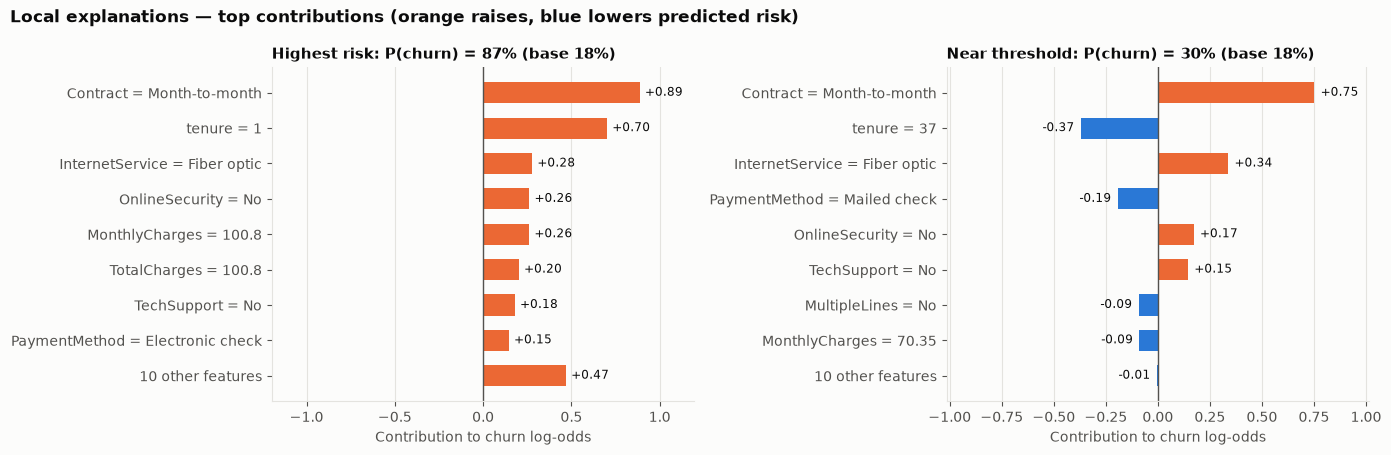

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, label in zip(axes, ["Highest risk", "Near threshold"]):
    exp = local[label]
    table = exp.top(8)[::-1]
    names = [f"{f} = {v}" if v != "" else f for f, v in zip(table["feature"], table["value"])]
    colors = np.where(table["contribution"] > 0, ORANGE, BLUE)
    ax.barh(names, table["contribution"], color=colors, height=0.6)
    for y, v in enumerate(table["contribution"]):
        ax.text(v + (0.03 if v >= 0 else -0.03), y, f"{v:+.2f}", va="center",
                ha="left" if v >= 0 else "right", fontsize=8.5, color=TEXT)
    ax.axvline(0, color=MUTED, lw=1)
    lim = np.abs(table["contribution"]).max() * 1.35
    ax.set_xlim(-lim, lim)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("Contribution to churn log-odds")
    ax.set_title(f"{label}: P(churn) = {exp.predicted_probability:.0%} "
                 f"(base {exp.base_probability:.0%})")
fig.suptitle("Local explanations — top contributions (orange raises, blue lowers predicted risk)",
             x=0.01, ha="left", fontweight="bold", color=TEXT)
fig.tight_layout()
save(fig, "23_local_explanations")
plt.show()

## 5. Findings

These describe how the model uses features (associations in this dataset), not causes of churn.

**Global**
- **Contract dominates.** Largest mean |SHAP| (0.77 log-odds) and largest single-feature permutation drop (ROC-AUC −0.094). Month-to-month raises predicted risk on average (+0.79); two-year contracts lower it strongly (−1.05).
- **Correlated groups matter more than any single member.** Shuffling *internet service + add-ons* together drops ROC-AUC by 0.063 and *tenure + charges* by 0.051. Their members shuffled alone drop much less (tenure 0.038, InternetService 0.019, MonthlyCharges 0.007, TotalCharges 0.002), because the model can partly fall back on correlated partners. Individual importances inside these groups should not be over-interpreted.
- **Tenure:** risk contribution is highest in the first months and declines steadily; long-tenure customers get strongly negative contributions.
- **MonthlyCharges:** contributions turn positive above roughly $80/month and plateau above ~$100 (the fiber-optic price range).
- **TotalCharges** adds little on its own (small positive for very low totals, i.e. new customers). This is consistent with Phase 4, where it gave only a small gain: most of its information is already in tenure and MonthlyCharges.
- **Services and billing:** fiber optic (+0.28), no OnlineSecurity (+0.21), no TechSupport (+0.15), electronic check (+0.19), and paperless billing (+0.08) raise predicted risk; "No internet service" lowers it.
- **Little or no use:** gender, Partner (never used by the trees), DeviceProtection, Dependents, SeniorCitizen. SeniorCitizen was associated with churn in EDA (41.7% vs. 23.6%) but contributes little here — once contract, charges, and services are known, it adds little extra information. Univariate association and a model's conditional use of a feature are different things.

**Local** (in-sample training customers, illustrating the mechanism)
- Highest-risk customer (P = 87%): month-to-month (+0.89), 1 month tenure (+0.70), fiber optic, no online security, high monthly charges — all push risk up from the 18% base.
- Near-threshold customer (P = 30%, flagged at 0.30): month-to-month (+0.75) and fiber optic (+0.34) raise risk, offset by 37 months of tenure (−0.37) and paying by mailed check (−0.19).

**Caveats**
- SHAP values are relative to the model's average (base 18.2%, i.e. expit of the mean log-odds — not the 26.5% churn rate).
- Contributions add in log-odds, not in percentage points.
- Tree-path-dependent SHAP follows the correlations learned by the trees; credit shared among correlated features (tenure/charges, internet/add-ons) is not uniquely identifiable. Group-level statements are more robust than feature-level ones within a group.